In [1]:
import os 
import json 
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({'text.usetex': True,'font.size':16, 'font.family':'serif'})

In [2]:
def stats(data, val):
    empirical_p = sum(d <= val for d in data) / len(data)
    
    mean = np.mean(data)
    std_dev = np.std(data)
    effective_z = (val - mean) / std_dev

    median_ratio = val / np.median(data)

    print(f"""r: {val:.4f}
Empirical p-value: {empirical_p*100:.4f} % 
Effective z-score: {effective_z:.4f}
Median ratio: {median_ratio:.4f}""")

    return empirical_p, effective_z, median_ratio

In [3]:
def inplot(data, val, r, ax, bins=200):
    dist = np.array(sorted(data))
    prob = val
    rad = r

    n, bins, patches = ax.hist(dist, bins=bins, density=True, cumulative=-1, range=(0.0, 0.3))
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    cm = plt.cm.get_cmap('magma_r')
    col = bin_centers - min(bin_centers)
    col /= max(col)

    for c, p in zip(col, patches):
        plt.setp(p, 'facecolor', cm(c))

    ax.axvline(x=r, color='k', linestyle='--', label=f'$r_{{10}}^{{true}}$ = ${r:.4f}"$')
    ax.axhline(y=1-prob, color='k', label=f'1 - FAP = ${(1-prob)*100:.2f}\%$')
    ax.set_ylabel('1 - CDF')
    ax.set_xlim(0,0.3)
    ax.set_ylim(0,1.05)
    ax.tick_params(axis='both', direction='in', length=10, width=1)
    ax.legend(loc=(0.5,0.1))

    #create inset axes
    axins = inset_axes(ax, width="50%", height="50%", loc=1)
    n, bins, patches = axins.hist(dist, bins=bins, density=True, cumulative=-1, range=(0.0, 0.2), color='gray')
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    col = bin_centers - min(bin_centers)
    col /= max(col)

    for c, p in zip(col, patches):
        plt.setp(p, 'facecolor', cm(c)) 

    axins.axvline(x=r, color='k', linestyle='--')
    axins.axhline(y=1-prob, color='k')

    xmin = np.round(r, 2) - 0.01
    xmin = max(xmin, 0)
    xmax = np.round(r, 2) + 0.01
    ymin = np.round(1-prob, 2) - 0.01
    ymax = 1.005

    axins.set_xlim(xmin, xmax)
    axins.set_ylim(ymin, ymax)
    axins.tick_params(axis='both', direction='in', length=10, width=1)

    return

def plot(data1, data2, data3, 
         val1, val2, val3, 
         r1, r2, r3, 
         filename='plot.png'):

    fig, axes = plt.subplots(3, 1, figsize=(8, 12))
    cm = plt.cm.get_cmap('magma_r')

    # plot the first inverse cdf 
    ax = axes[0]
    dist = np.array(sorted(data1))
    prob = val1
    rad = r1

    inplot(data1, val1, r1, ax,bins=1000)
    ax.text(0.28,0.05, '(a)', fontsize=24)
    ax.set_xticklabels([])

    # plot the second inverse cdf
    ax = axes[1]
    dist = np.array(sorted(data2))
    prob = val2
    rad = r2    

    inplot(data2, val2, r2, ax, bins=1000)
    ax.text(0.28,0.05, '(b)', fontsize=24)
    ax.set_xticklabels([])

    # plot the third inverse cdf
    ax = axes[2]
    dist = np.array(sorted(data3))
    prob = val3
    rad = r3

    inplot(data3, val3, r3, ax, bins=1000)
    ax.text(0.28,0.05, '(c)', fontsize=24)
    ax.set_xlabel('$r_{10}$ (arcsec)')

    plt.subplots_adjust(left=None, bottom=0, right=None, top=None, wspace=None, hspace=0.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

In [4]:
bestjson = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/best/results.json'
avgjson = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/average/results.json'
worstjson = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/small/results.json'

best = json.load(open(bestjson))
avg = json.load(open(avgjson))
worst = json.load(open(worstjson))

In [5]:
r_best = best['true_90th_percentile']
data_best = best['all_90th_percentiles']
val_best = best['probability']

r_avg = avg['true_90th_percentile']
data_avg = avg['all_90th_percentiles']
val_avg = avg['probability']

r_worst = worst['true_90th_percentile']
data_worst = worst['all_90th_percentiles']
val_worst = worst['probability']

In [6]:
plot(data_worst, data_avg, data_best, 
     val_worst, val_avg, val_best, 
     r_worst, r_avg, r_best, 
     filename='astrophysical.pdf')

/local/lauraelina.uronen/ipykernel_2949622/2779705543.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('magma_r')
/local/lauraelina.uronen/ipykernel_2949622/2779705543.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('magma_r')
/local/lauraelina.uronen/ipykernel_2949622/2779705543.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('magma_r')
/local/lauraelina.uronen/ipykernel_2949622/27797055

In [7]:
len(data_worst)

10000

In [8]:
print("Worst case stats:")
stats(data_worst, r_worst)

print("Average case stats:")
stats(data_avg, r_avg)

print("Best case stats:")
stats(data_best, r_best)

Worst case stats:
r: 0.0121
Empirical p-value: 1.9400 % 
Effective z-score: -1.7241
Median ratio: 0.2261
Average case stats:
r: 0.0113
Empirical p-value: 0.5800 % 
Effective z-score: -1.8286
Median ratio: 0.1510
Best case stats:
r: 0.0312
Empirical p-value: 0.0600 % 
Effective z-score: -4.0750
Median ratio: 0.1545


(0.0006, np.float64(-4.074971898506301), np.float64(0.15446512098973425))

In [9]:
json5 = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/unc_5/results.json'
json10 = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/unc_10/results.json'
jsonprio = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/rrel/results.json'

j5 = json.load(open(json5))
j10 = json.load(open(json10))
prior = json.load(open(jsonprio))

In [10]:
print(len(j5['all_90th_percentiles']))
print("Uncertainty 5 case stats:")
dat5 = j5['all_90th_percentiles']
true5 = j5['true_90th_percentile']
val5 = j5['probability']
stats(dat5, true5)

print(len(j10['all_90th_percentiles']))
print("Uncertainty 10 case stats:")
dat10 = j10['all_90th_percentiles']
true10 = j10['true_90th_percentile']
val10 = j10['probability']
stats(dat10, true10)

print(len(prior['all_90th_percentiles']))
print("Gaussian prior case stats:")
datprio = prior['all_90th_percentiles']
trueprio = prior['true_90th_percentile']
valprio = prior['probability']
stats(datprio, trueprio)

10000
Uncertainty 5 case stats:
r: 0.0121
Empirical p-value: 0.5500 % 
Effective z-score: -1.8206
Median ratio: 0.1578
10000
Uncertainty 10 case stats:
r: 0.0392
Empirical p-value: 7.5400 % 
Effective z-score: -1.2780
Median ratio: 0.5104
10000
Gaussian prior case stats:
r: 0.0022
Empirical p-value: 0.1500 % 
Effective z-score: -1.6983
Median ratio: 0.0350


(0.0015, np.float64(-1.6983467842141653), np.float64(0.0350054617745319))

In [11]:
vals = [val_worst, val_avg, val_best, val5, val10]
re = [0.5,1.0,1.8,1.0,1.0]
unc = [1,1,1,5,10]

unc1s = np.array([val_worst, val_avg, val_best])*100
unc1s = np.log10(unc1s)
re1s = np.array([0.5,1.0,1.8])

coeffs = np.polyfit(re1s, unc1s, 1)
m, b = coeffs 

xline = np.linspace(0,2.0,100)
yline = m * xline + b
yline = 10**yline

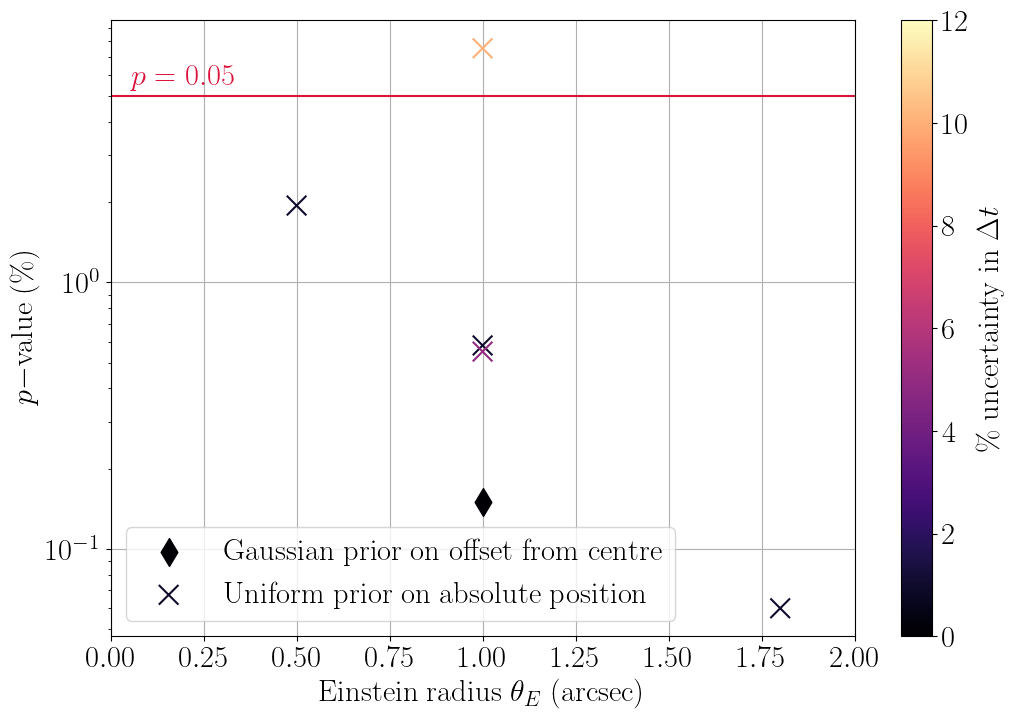

In [37]:
plt.rcParams.update({'text.usetex': True,'font.size':22, 'font.family':'serif'})

plt.figure(figsize=(12,8))
plt.grid(zorder=1)
plt.scatter(1.0,valprio*100, c=1, marker='d', zorder=3, cmap='magma', s=200, label='Gaussian prior on offset from centre')
plt.scatter(re, np.asarray(vals)*100, c=unc, marker='x', zorder=3, cmap='magma', s=200, label='Uniform prior on absolute position')
plt.axhline(5, c='crimson')
plt.text(0.051, 5.5, r'$p = 0.05$', c='crimson')
plt.yscale('log')
cbar = plt.colorbar(label=r"$\%$ uncertainty in $\Delta t$")
cbar.mappable.set_clim(0,12)
plt.xlabel(r'Einstein radius $\theta_E$ (arcsec)')
plt.ylabel(r"$p-$value ($\%$)")
plt.xlim(0,2.0)
plt.legend()
plt.savefig('summary.pdf', dpi=300)

In [14]:
from astropy.cosmology import Planck18 as cosmo

In [23]:
def conv_arcsec_to_pc(arcsec, z):
    kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(z).value / 60.0
    return arcsec * kpc_per_arcsec * 1000


In [24]:
z_small = 2.0
z_mid = 1.5
z_big = 0.8

small = conv_arcsec_to_pc(r_worst, z_small)
mid = conv_arcsec_to_pc(r_worst, z_mid)
big = conv_arcsec_to_pc(r_worst, z_big)

five = conv_arcsec_to_pc(true5, z_mid)
ten = conv_arcsec_to_pc(true10, z_mid)
prio = conv_arcsec_to_pc(trueprio, z_mid)

print(f"Small Einstein radius ({z_small}): {small:.2f} pc")
print(f"Medium Einstein radius ({z_mid}): {mid:.2f} pc")
print(f"Large Einstein radius ({z_big}): {big:.2f} pc")
print(f"Uncertainty 5 case: {five:.2f} pc")
print(f"Uncertainty 10 case: {ten:.2f} pc")
print(f"Gaussian prior case: {prio:.2f} pc")

Small Einstein radius (2.0): 103.64 pc
Medium Einstein radius (1.5): 104.90 pc
Large Einstein radius (0.8): 93.32 pc
Uncertainty 5 case: 104.96 pc
Uncertainty 10 case: 339.97 pc
Gaussian prior case: 18.90 pc
